In [ ]:
!nvidia-smi

Fri Apr 24 18:05:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.5 MB/s eta 0:00:00


In [ ]:
!ls /content/

drive  sample_data  yolo11n.pt


In [ ]:
from ultralytics import YOLO

# Load the YOLOv11 Nano model
model = YOLO("yolo11n.pt")

# Train the model and save progress directly to Google Drive
results = model.train(
    data="/content/drive/MyDrive/DeepSight/data.yaml", # Path to your updated yaml
    project="/content/drive/MyDrive/DeepSight/runs",   # <--- SAVES DIRECTLY TO YOUR DRIVE
    name="plate_detector",                             # Creates a folder named 'plate_detector'

    epochs=20,
    imgsz=416,
    batch=16,
    device="0",         # Uses the Colab GPU

    # Robustness Augmentations
    mosaic=1.0,
    mixup=0.2,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DeepSight/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detector-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

Loading custom plate detector...
Running inference on 10 samples...
Result for 000000.jpg:


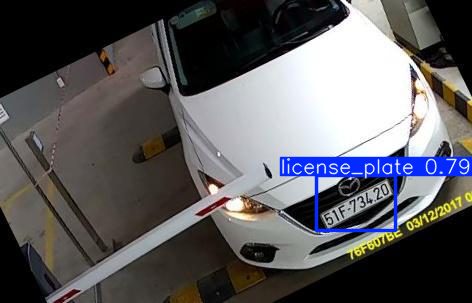

------------------------------
Result for 000001.jpg:


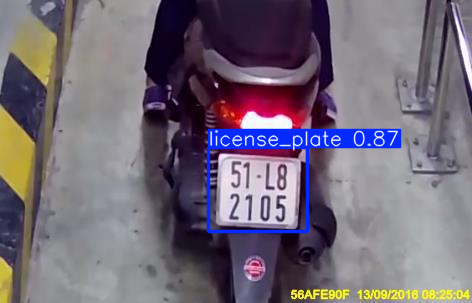

------------------------------
Result for 000002.jpg:


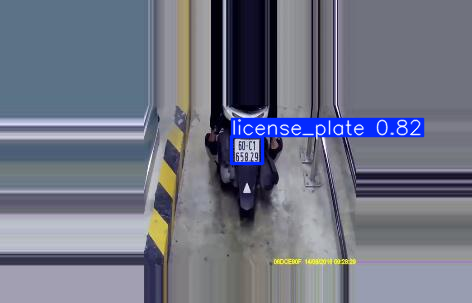

------------------------------
Result for 000003.jpg:


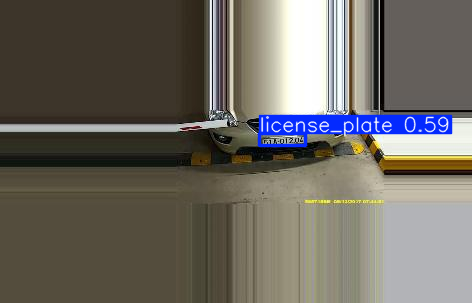

------------------------------
Result for 000004.jpg:


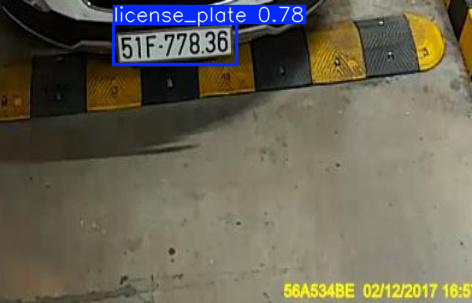

------------------------------
Result for 000005.jpg:


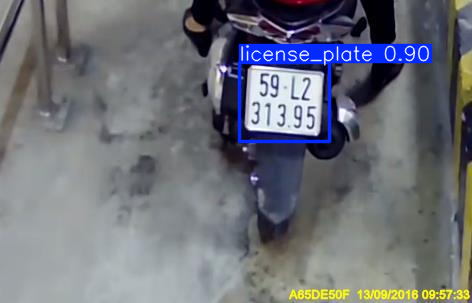

------------------------------
Result for 000006.jpg:


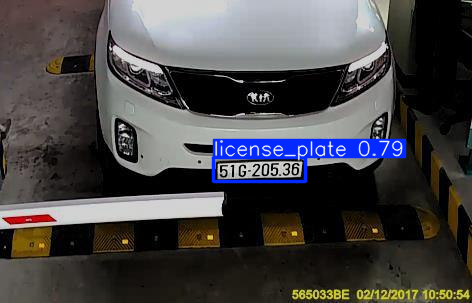

------------------------------
Result for 000007.jpg:


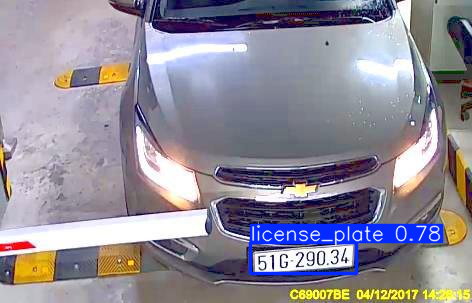

------------------------------
Result for 000008.jpg:


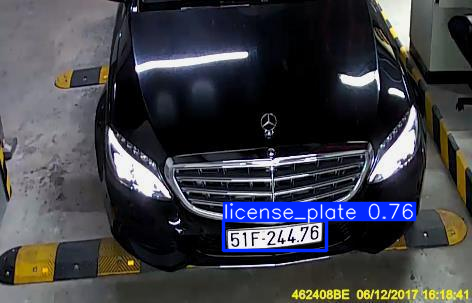

------------------------------
Result for 000009.jpg:


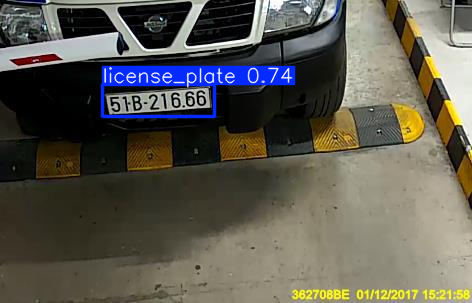

------------------------------
✅ All test images saved to: /content/drive/MyDrive/DeepSight/test_results_visuals


In [ ]:
import os
import glob
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow # Special function to view images in Colab

# 1. Path to your NEWLY TRAINED weights
# Based on your log, it's saved in plate_detector-4
MODEL_PATH = "/content/drive/MyDrive/DeepSight/runs/plate_detector-4/weights/best.pt"

# 2. Path to images you want to test
# You can point this to your 'train_set/images' or a separate test folder
TEST_IMAGES_DIR = "/content/drive/MyDrive/DeepSight/train_set/images"
OUTPUT_DIR = "/content/drive/MyDrive/DeepSight/test_results_visuals"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load the model
print(f"Loading custom plate detector...")
model = YOLO(MODEL_PATH)

# Get 10 sample images to check visually
image_paths = sorted(glob.glob(os.path.join(TEST_IMAGES_DIR, "*.jpg")))[:10]

print(f"Running inference on {len(image_paths)} samples...")

for img_path in image_paths:
    # Run prediction (using imgsz=320 to keep GFLOPs low as we discussed)
    results = model.predict(source=img_path, conf=0.5, imgsz=320, verbose=False)

    for r in results:
        # Use plot() to draw the bounding boxes automatically
        annotated_image = r.plot()

        # Save to Drive so you have a record
        fname = os.path.basename(img_path)
        save_path = os.path.join(OUTPUT_DIR, f"pred_{fname}")
        cv2.imwrite(save_path, annotated_image)

        # Display the image right here in the Colab output
        print(f"Result for {fname}:")
        cv2_imshow(annotated_image)
        print("-" * 30)

print(f"✅ All test images saved to: {OUTPUT_DIR}")

In [ ]:
import os
from ultralytics import YOLO
from tqdm import tqdm
import cv2

# 1. Paths
MODEL_PATH = "/content/drive/MyDrive/DeepSight/runs/plate_detector-4/weights/best.pt"
INPUT_DIR = "/content/drive/MyDrive/DeepSight/train_set/images"
OUTPUT_DIR = "/content/drive/MyDrive/DeepSight/train_set/result_images"

def run_full_inference():
    # Ensure output directory exists
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR, exist_ok=True)

    # 2. Load your high-accuracy model
    print("Loading custom plate detector...")
    model = YOLO(MODEL_PATH)

    # 3. Get list of all images
    # We filter for common image extensions
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    image_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(valid_extensions)]

    print(f"🚀 Starting inference on {len(image_files)} images...")

    # 4. Use stream=True to process images one-by-one efficiently
    # imgsz=320 ensures we stay under the 5 GFLOPs limit for the whole run
    for img_name in tqdm(image_files, desc="Drawing Bounding Boxes", unit="img"):
        img_path = os.path.join(INPUT_DIR, img_name)

        # Perform prediction
        # We use a higher confidence (0.5) to ensure only clean detections are saved
        results = model.predict(source=img_path, conf=0.5, imgsz=320, verbose=False)

        for r in results:
            # Generate the image with the bounding box drawn
            annotated_frame = r.plot()

            # Save the result to your Drive folder
            save_path = os.path.join(OUTPUT_DIR, img_name)
            cv2.imwrite(save_path, annotated_frame)

    print(f"\n✅ SUCCESS! All processed images are in: {OUTPUT_DIR}")

if __name__ == "__main__":
    run_full_inference()

Loading custom plate detector...
🚀 Starting inference on 6177 images...


Drawing Bounding Boxes: 100%|██████████| 6177/6177 [03:59<00:00, 25.81img/s]


✅ SUCCESS! All processed images are in: /content/drive/MyDrive/DeepSight/train_set/result_images
